In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches


In [12]:
df = pd.read_pickle("../data/filtered/cleaned_articles (1).pkl")
df.head()

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Egypt, Nicaragua, Mexico, Canada]","[Washington, Massachusetts, US, Rhode Island]",NYT/1.DOCX,The New York Times
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[Sierra Leone, Japan, France, United Kingdom]","[Georgia, New Jersey, America, USA, California...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio)
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,US_ONLY,[],"[US, North Carolina, United States, New York]",NYT/1.DOCX,The New York Times
3,"Under a Highway in Rio, a Dance Style Charms a...",New York Times,2024-12-31,WORLD; americas,"Trucks, buses and cars rumbled overhead, drown...",1333,False,BOTH,[Brazil],"[US, United States, New York]",NYT/1.DOCX,The New York Times
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[New Jersey, Pennsylvania, America, Delaware, ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer


In [14]:
print("Column names:")
print(df.columns.tolist())

Column names:
['title', 'publisher', 'date', 'section', 'body', 'length', 'letters_flag', 'country_flag', 'foreign_countries', 'us_mentions', 'source_file', 'publisher_raw']


/var/folders/d9/z9bzkbj143b47cv2wkf7c1780000gn/T/ipykernel_12925/1901934330.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


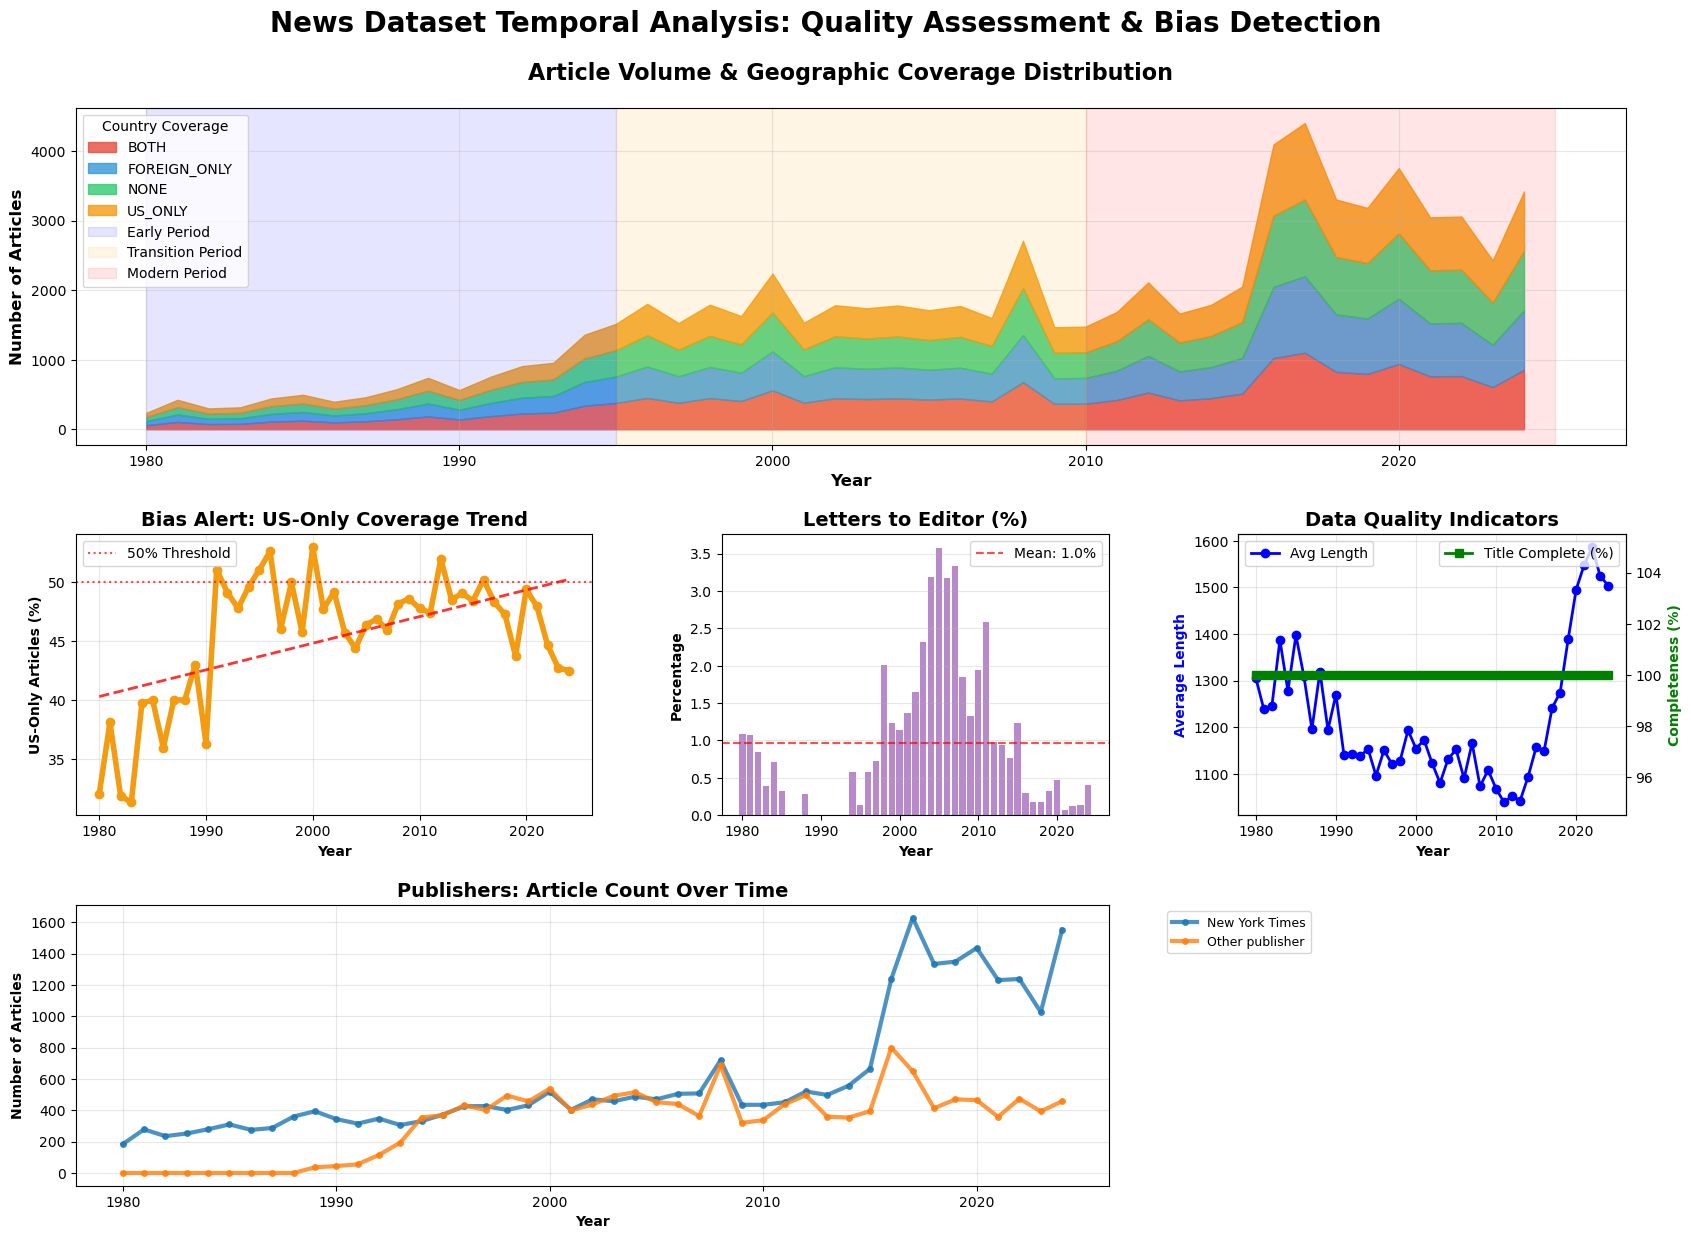

In [33]:

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Set up professional styling
plt.style.use('default')
sns.set_palette("husl")

# Create figure with custom layout
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, height_ratios=[1.2, 1, 1], width_ratios=[2, 1.5, 1.5], 
                      hspace=0.3, wspace=0.3)

# Define professional color palette
colors = {
    'BOTH': '#E74C3C',      # Red
    'FOREIGN_ONLY': '#3498DB',  # Blue  
    'NONE': '#2ECC71',      # Green
    'US_ONLY': '#F39C12',   # Orange
    'letters_true': '#9B59B6',  # Purple
    'letters_false': '#95A5A6', # Gray
    'trend': '#E74C3C',     # Red for trend lines
    'volume': '#34495E'     # Dark gray for volume
}

# Main title
fig.suptitle('News Dataset Temporal Analysis: Quality Assessment & Bias Detection', 
             fontsize=20, fontweight='bold', y=0.95)

# 1. MAIN CHART: Country Distribution Over Time (NO BLACK LINE)
ax1 = fig.add_subplot(gs[0, :])

# Create yearly aggregations
df_yearly = df.groupby(df['date'].dt.year).agg({
    'country_flag': ['count'] + [lambda x: (x == flag).sum() for flag in ['BOTH', 'FOREIGN_ONLY', 'NONE', 'US_ONLY']]
}).reset_index()

# Flatten column names
df_yearly.columns = ['year', 'total'] + ['BOTH', 'FOREIGN_ONLY', 'NONE', 'US_ONLY']

# Create stacked area chart ONLY
years = df_yearly['year']
bottom = np.zeros(len(years))

for flag in ['BOTH', 'FOREIGN_ONLY', 'NONE', 'US_ONLY']:
    if flag in df_yearly.columns:
        values = df_yearly[flag]
        ax1.fill_between(years, bottom, bottom + values, 
                        alpha=0.8, color=colors[flag], label=flag)
        bottom += values

# Styling for main chart
ax1.set_title('Article Volume & Geographic Coverage Distribution', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Articles', fontsize=12, fontweight='bold')

# Add trend periods with background shading
ax1.axvspan(1980, 1995, alpha=0.1, color='blue', label='Early Period')
ax1.axvspan(1995, 2010, alpha=0.1, color='orange', label='Transition Period')
ax1.axvspan(2010, 2025, alpha=0.1, color='red', label='Modern Period')

# Legend ONLY for country coverage
ax1.legend(title='Country Coverage', loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. BIAS DETECTION: US Coverage Percentage
ax2 = fig.add_subplot(gs[1, 0])

us_pct = (df_yearly['US_ONLY'] / df_yearly['total'] * 100)
ax2.plot(years, us_pct, color=colors['US_ONLY'], linewidth=4, marker='o', markersize=6)

# Add trend line
z = np.polyfit(years, us_pct, 1)
p = np.poly1d(z)
ax2.plot(years, p(years), "--", color='red', linewidth=2, alpha=0.8)

# Add critical threshold line
ax2.axhline(y=50, color='red', linestyle=':', alpha=0.7, label='50% Threshold')

ax2.set_title('Bias Alert: US-Only Coverage Trend', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontweight='bold')
ax2.set_ylabel('US-Only Articles (%)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Add trend annotation
slope = z[0]
if abs(slope) > 0.5:
    trend_text = f" Strong trend: {slope:+.2f}%/year"
    ax2.text(0.05, 0.95, trend_text, transform=ax2.transAxes, 
             fontsize=11, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

# 3. LETTERS TO EDITOR ANALYSIS
ax3 = fig.add_subplot(gs[1, 1])

letters_yearly = df.groupby(df['date'].dt.year)['letters_flag'].agg(['sum', 'count']).reset_index()
letters_pct = (letters_yearly['sum'] / letters_yearly['count'] * 100)

ax3.bar(letters_yearly['date'], letters_pct, color=colors['letters_true'], 
        alpha=0.7, width=0.8)
ax3.set_title('Letters to Editor (%)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year', fontweight='bold')
ax3.set_ylabel('Percentage', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add mean line
mean_letters = letters_pct.mean()
ax3.axhline(y=mean_letters, color='red', linestyle='--', alpha=0.7, 
           label=f'Mean: {mean_letters:.1f}%')
ax3.legend()

# 4. DATA QUALITY INDICATORS
ax4 = fig.add_subplot(gs[1, 2])

# Calculate quality metrics
quality_metrics = df.groupby(df['date'].dt.year).agg({
    'length': 'mean',
    'title': lambda x: x.notna().mean() * 100,
    'body': lambda x: x.notna().mean() * 100
}).reset_index()

ax4.plot(quality_metrics['date'], quality_metrics['length'], 
         marker='o', linewidth=2, label='Avg Length', color='blue')
ax4_twin = ax4.twinx()
ax4_twin.plot(quality_metrics['date'], quality_metrics['title'], 
              marker='s', linewidth=2, label='Title Complete (%)', color='green')

ax4.set_title('Data Quality Indicators', fontsize=14, fontweight='bold')
ax4.set_xlabel('Year', fontweight='bold')
ax4.set_ylabel('Average Length', fontweight='bold', color='blue')
ax4_twin.set_ylabel('Completeness (%)', fontweight='bold', color='green')

ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

# 5. PUBLISHER ANALYSIS
ax5 = fig.add_subplot(gs[2, :2])

# Top publishers over time
top_publishers = df['publisher'].value_counts().head(5).index
publisher_yearly = df[df['publisher'].isin(top_publishers)].groupby([
    df['date'].dt.year, 'publisher']).size().unstack(fill_value=0)

# Create line plot instead of stacked area for better visibility
colors_pub = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, pub in enumerate(publisher_yearly.columns):
    ax5.plot(publisher_yearly.index, publisher_yearly[pub], 
             linewidth=3, marker='o', markersize=4, alpha=0.8,
             color=colors_pub[i % len(colors_pub)], label=pub)

ax5.set_title('Publishers: Article Count Over Time', 
              fontsize=14, fontweight='bold')
ax5.set_xlabel('Year', fontweight='bold')
ax5.set_ylabel('Number of Articles', fontweight='bold')
ax5.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. KEY STATISTICS PANEL
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

# Calculate key statistics
total_articles = len(df)
date_range = f"{df['date'].min().year}-{df['date'].max().year}"
us_only_pct = (df['country_flag'] == 'US_ONLY').mean() * 100
letters_pct_total = df['letters_flag'].mean() * 100
yearly_growth = df.groupby(df['date'].dt.year).size()
growth_rate = ((yearly_growth.iloc[-1] / yearly_growth.iloc[0]) ** (1/(len(yearly_growth)-1)) - 1) * 100
